# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [13]:
# 변수 선택/해석용 패키지 (최초 1회만 설치)
# !pip install mrmr-selection boruta shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv("dataset/day5_miniproject.csv")
TARGET = "Churn"

print("데이터 크기:", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())
df.head()

데이터 크기: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

In [14]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ===== Day4 미니프로젝트 전처리 재현 =====
data = df.copy()

# 1) 타입 정리
#    - TotalCharges: 공백/문자 혼재 → 숫자 변환 (변환 실패값은 NaN)
#    - SeniorCitizen: 0/1 수치이지만 범주 의미 → No/Yes 로 변환
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["SeniorCitizen"] = data["SeniorCitizen"].map({0: "No", 1: "Yes"})

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in data.select_dtypes(include="object").columns if c != TARGET]

# 2) 결측치 처리: 수치형은 KNN Imputer, 범주형은 최빈값
imputer = KNNImputer(n_neighbors=5)
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])
for col in cat_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])
print("결측치 처리 후 총 결측 개수:", data.isnull().sum().sum())

# 3) 이상치 처리: 행 단위 IQR 이상치가 2개 이상인 행만 제거
#    (단일 극단값은 이탈 고객 정보일 수 있어 소수 클래스를 보존하기 위해 보수적으로 적용)
q1 = data[numeric_cols].quantile(0.25)
q3 = data[numeric_cols].quantile(0.75)
iqr = q3 - q1
is_outlier = (data[numeric_cols] < (q1 - 1.5 * iqr)) | (data[numeric_cols] > (q3 + 1.5 * iqr))
rows_to_drop = is_outlier.sum(axis=1)[is_outlier.sum(axis=1) > 1].index
data_clean = data.drop(index=rows_to_drop).copy()
print(f"이상치 제거: {len(data)}행 → {len(data_clean)}행 (삭제 {len(rows_to_drop)}행)")

# 4) 입력/출력 분리 + Stratified train/test split (클래스 불균형 유지)
y = data_clean[TARGET].map({"No": 0, "Yes": 1})
X = data_clean.drop(columns=[TARGET])
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) 스케일링/인코딩: 수치형 StandardScaler, 범주형 OneHotEncoder(drop='first')
cat_cols = X_train_raw.select_dtypes(include="object").columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)
X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

feature_names = numeric_cols + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
)
X_train = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test_raw.index)

print("전처리 후 학습 데이터:", X_train.shape, "| 테스트 데이터:", X_test.shape)
print("\n[Train] 클래스 분포:")
print(y_train.value_counts())
X_train.head()

결측치 처리 후 총 결측 개수: 0
이상치 제거: 7043행 → 7043행 (삭제 0행)
전처리 후 학습 데이터: (5634, 30) | 테스트 데이터: (1409, 30)

[Train] 클래스 분포:
Churn
0    4139
1    1495
Name: count, dtype: int64


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.113235,-0.523555,-0.262824,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.702748,0.338061,-0.504294,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.759867,-0.811314,-0.750635,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,-0.253957,0.284833,-0.173255,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,-1.273936,-0.678246,-0.990217,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

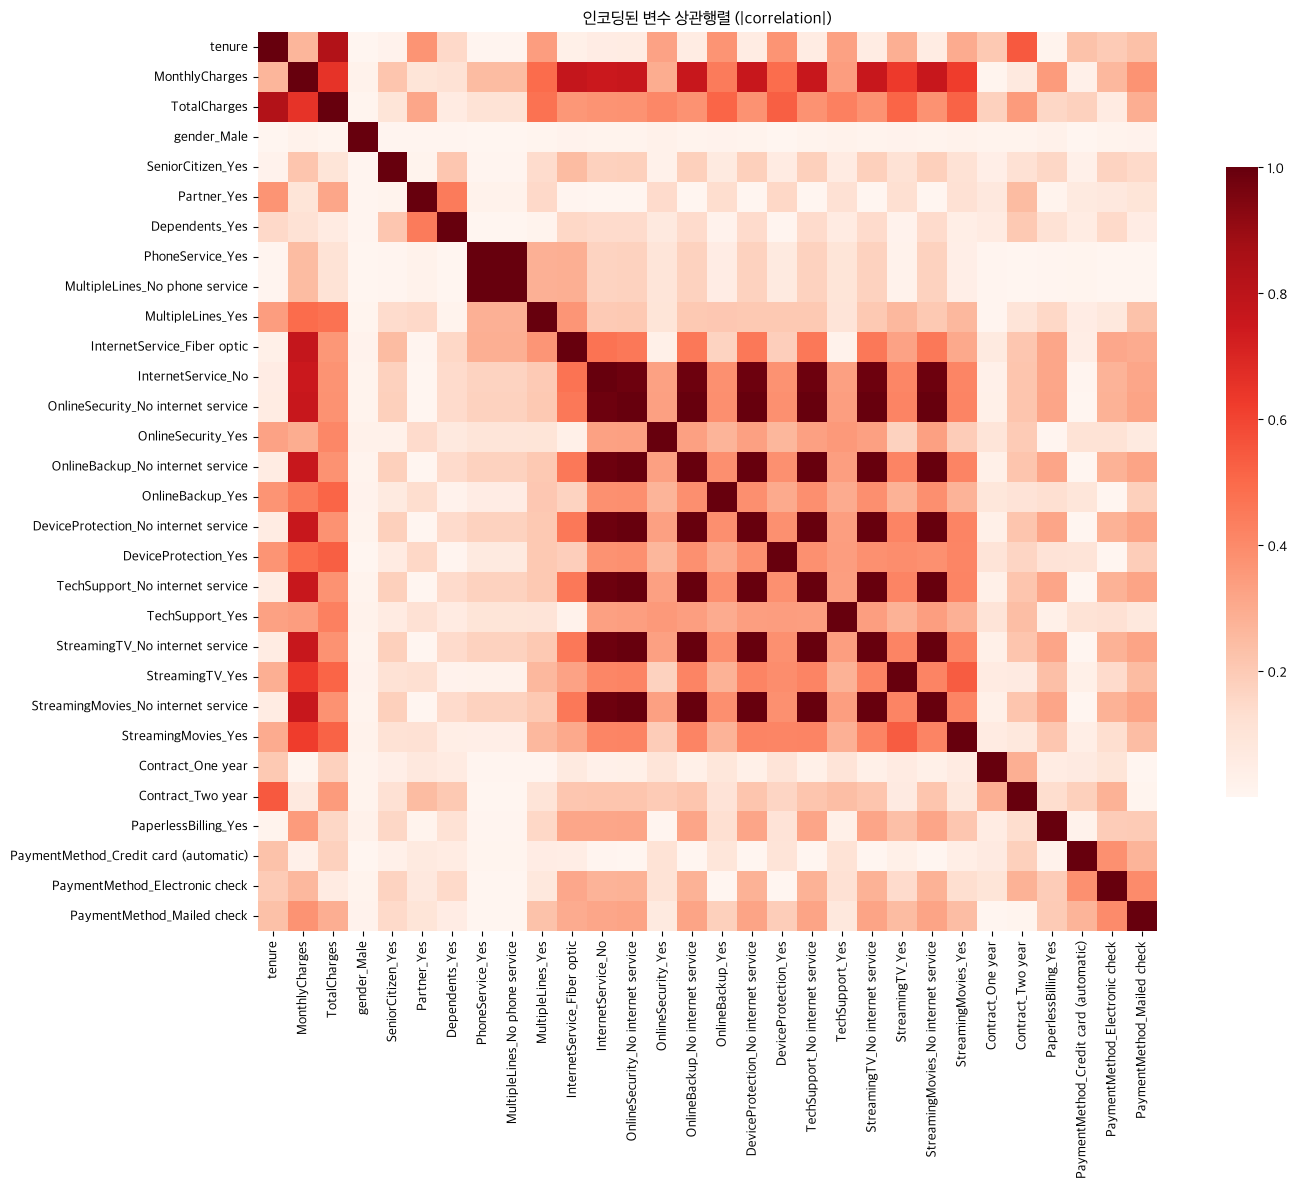

=== |상관계수| >= 0.7 인 변수쌍 (다중공선성 의심) ===
StreamingTV_No internet service       StreamingMovies_No internet service     1.000000
DeviceProtection_No internet service  TechSupport_No internet service         1.000000
OnlineBackup_No internet service      DeviceProtection_No internet service    1.000000
DeviceProtection_No internet service  StreamingMovies_No internet service     1.000000
TechSupport_No internet service       StreamingTV_No internet service         1.000000
OnlineBackup_No internet service      TechSupport_No internet service         1.000000
                                      StreamingTV_No internet service         1.000000
                                      StreamingMovies_No internet service     1.000000
OnlineSecurity_No internet service    StreamingMovies_No internet service     1.000000
                                      StreamingTV_No internet service         1.000000
TechSupport_No internet service       StreamingMovies_No internet service     1.000000
Devi

In [15]:
# 인코딩된 변수들의 상관행렬 히트맵
corr = X_train.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr.abs(), cmap="Reds", square=True, cbar_kws={"shrink": 0.7})
plt.title("인코딩된 변수 상관행렬 (|correlation|)")
plt.tight_layout()
plt.show()

# 상관관계가 높은 변수쌍 확인 (상삼각만 추출)
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("=== |상관계수| >= 0.7 인 변수쌍 (다중공선성 의심) ===")
high_corr = corr_pairs[corr_pairs >= 0.7]
print(high_corr if len(high_corr) else "없음")

print("\n=== 상관관계 상위 10개 변수쌍 ===")
print(corr_pairs.head(10).round(3))

**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# 분류 성능 평가 함수 (전체 변수 / mRMR / Boruta 결과를 동일 기준으로 비교)
def get_classscore(real, pred):
    return {
        "Accuracy": accuracy_score(real, pred),
        "Precision": precision_score(real, pred, zero_division=0),
        "Recall": recall_score(real, pred, zero_division=0),
        "F1-score": f1_score(real, pred, zero_division=0),
    }

def print_classscore(name, real, pred):
    s = get_classscore(real, pred)
    print(f"[{name}]")
    for k, v in s.items():
        print(f"  {k:10s}: {v:.4f}")
    print("  혼동행렬 (행=실제, 열=예측):")
    print(confusion_matrix(real, pred))
    return s

# 전체 변수를 사용한 Random Forest 분류 모델 (이후 비교의 기준점)
rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
rf_all.fit(X_train, y_train)
pred_all = rf_all.predict(X_test)

score_all = print_classscore(f"전체 변수 ({X_train.shape[1]}개)", y_test, pred_all)

[전체 변수 (30개)]
  Accuracy  : 0.7963
  Precision : 0.6485
  Recall    : 0.5080
  F1-score  : 0.5697
  혼동행렬 (행=실제, 열=예측):
[[932 103]
 [184 190]]


## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

In [17]:
from mrmr import mrmr_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score

# k 후보별 5-fold CV F1-score로 가장 적합한 k 결정
k_candidates = [5, 10, 15, 20, 25]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_scores = {}
for k in k_candidates:
    selected = mrmr_classif(X=X_train, y=y_train, K=k)
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_train[selected], y_train, cv=skf, scoring="f1",
    )
    k_scores[k] = scores.mean()
    print(f"k={k:>2}, CV F1={k_scores[k]:.4f}")

# CV F1이 가장 높은 k 선택
best_k = max(k_scores, key=k_scores.get)
selected_mrmr = mrmr_classif(X=X_train, y=y_train, K=best_k)
print(f"\n최적 k = {best_k} (CV F1={k_scores[best_k]:.4f})")
print(f"mRMR 선택 변수 ({len(selected_mrmr)}개): {selected_mrmr}")

# 선택된 변수만으로 다시 학습해 전체 변수 대비 성능 비교
rf_mrmr = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mrmr.fit(X_train[selected_mrmr], y_train)
pred_mrmr = rf_mrmr.predict(X_test[selected_mrmr])
score_mrmr = print_classscore(f"mRMR 선택 변수 (k={best_k})", y_test, pred_mrmr)

print("\n=== 전체 변수 vs mRMR 성능 비교 ===")
display(pd.DataFrame({"전체 변수": score_all, f"mRMR (k={best_k})": score_mrmr}).T.round(4))

100%|██████████| 5/5 [00:00<00:00, 12.94it/s]


k= 5, CV F1=0.5188


100%|██████████| 10/10 [00:00<00:00, 36.77it/s]


k=10, CV F1=0.5610


100%|██████████| 15/15 [00:00<00:00, 41.10it/s]


k=15, CV F1=0.5258


100%|██████████| 20/20 [00:00<00:00, 29.63it/s]


k=20, CV F1=0.5275


100%|██████████| 25/25 [00:01<00:00, 18.52it/s]


k=25, CV F1=0.5574


100%|██████████| 10/10 [00:01<00:00,  9.17it/s]



최적 k = 10 (CV F1=0.5610)
mRMR 선택 변수 (10개): ['tenure', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'PaperlessBilling_Yes', 'OnlineSecurity_Yes', 'Contract_One year', 'OnlineSecurity_No internet service', 'Dependents_Yes', 'OnlineBackup_No internet service']
[mRMR 선택 변수 (k=10)]
  Accuracy  : 0.7480
  Precision : 0.5255
  Recall    : 0.5241
  F1-score  : 0.5248
  혼동행렬 (행=실제, 열=예측):
[[858 177]
 [178 196]]

=== 전체 변수 vs mRMR 성능 비교 ===


,Accuracy,Precision,Recall,F1-score
전체 변수,0.7963,0.6485,0.5080,0.5697
mRMR (k=10),0.7480,0.5255,0.5241,0.5248


## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

In [18]:
from boruta import BorutaPy

# Boruta 내부 중요도 계산용 Random Forest 분류기
# n_estimators='auto': 트리 개수 자동 / max_iter: 반복 판단 횟수 / perc=100: 가장 엄격
rf_for_boruta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
boruta = BorutaPy(rf_for_boruta, n_estimators="auto", max_iter=50, perc=100, random_state=42)

# BorutaPy는 numpy 배열만 지원 → values 변환, y는 1차원(ravel)
boruta.fit(X_train.values, y_train.values.ravel())

confirmed = X_train.columns[boruta.support_].tolist()      # 확정 변수
tentative = X_train.columns[boruta.support_weak_].tolist()  # 미정 변수
print("총 변수:", X_train.shape[1])
print(f"Boruta 확정 변수 ({len(confirmed)}개): {confirmed}")
print(f"Boruta 미정 변수 ({len(tentative)}개): {tentative}")

# 확정 변수로 재학습 (확정 변수가 없으면 미정 변수까지 포함)
selected_boruta = confirmed if len(confirmed) > 0 else confirmed + tentative
rf_boruta = RandomForestClassifier(n_estimators=100, random_state=42)
rf_boruta.fit(X_train[selected_boruta], y_train)
pred_boruta = rf_boruta.predict(X_test[selected_boruta])
score_boruta = print_classscore(f"Boruta 선택 변수 ({len(selected_boruta)}개)", y_test, pred_boruta)

총 변수: 30
Boruta 확정 변수 (3개): ['tenure', 'MonthlyCharges', 'TotalCharges']
Boruta 미정 변수 (0개): []
[Boruta 선택 변수 (3개)]
  Accuracy  : 0.7502
  Precision : 0.5377
  Recall    : 0.4198
  F1-score  : 0.4715
  혼동행렬 (행=실제, 열=예측):
[[900 135]
 [217 157]]


## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

In [19]:
# 전체 변수 / mRMR / Boruta 세 방법의 성능을 하나의 표로 정리
summary = pd.DataFrame(
    [
        {"Method": "전체 변수", "변수 수": X_train.shape[1], **score_all},
        {"Method": f"mRMR (k={best_k})", "변수 수": len(selected_mrmr), **score_mrmr},
        {"Method": "Boruta", "변수 수": len(selected_boruta), **score_boruta},
    ]
).set_index("Method")

print("=== 변수 선택 방법별 성능 비교 ===")
display(summary.round(4))

# F1-score 기준 최고 성능 방법 (SHAP 분석 대상 모델)
best_method = summary["F1-score"].idxmax()
print(f"\nF1-score 기준 최고 성능: {best_method}")
print(
    f"→ 전체 {X_train.shape[1]}개 변수를 "
    f"mRMR {len(selected_mrmr)}개 / Boruta {len(selected_boruta)}개로 줄였을 때 "
    "성능이 어떻게 유지·변화하는지 위 표에서 비교해 보세요."
)

=== 변수 선택 방법별 성능 비교 ===


,변수 수,Accuracy,Precision,Recall,F1-score
Method,,,,,
전체 변수,30,0.7963,0.6485,0.5080,0.5697
mRMR (k=10),10,0.7480,0.5255,0.5241,0.5248
Boruta,3,0.7502,0.5377,0.4198,0.4715



F1-score 기준 최고 성능: 전체 변수
→ 전체 30개 변수를 mRMR 10개 / Boruta 3개로 줄였을 때 성능이 어떻게 유지·변화하는지 위 표에서 비교해 보세요.


## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

SHAP 분석 대상 모델: 전체 변수 (변수 30개)


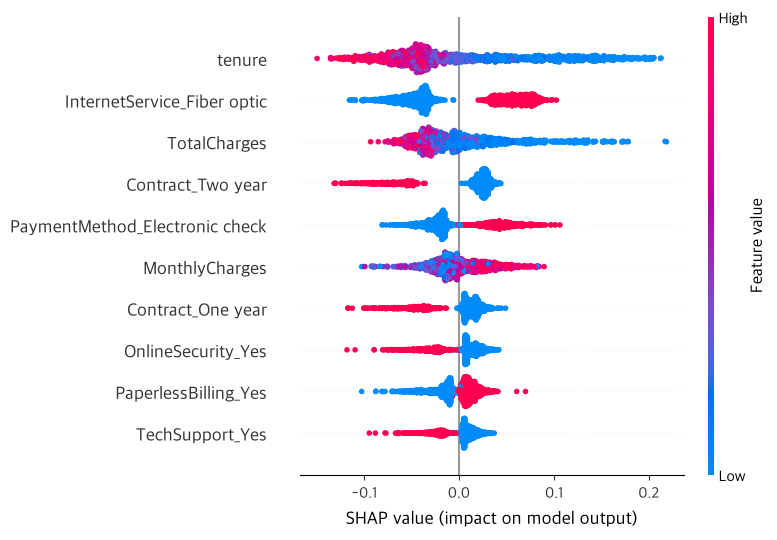

In [20]:
import shap

# 성능이 가장 좋았던 모델/변수 집합 선택
model_registry = {
    "전체 변수": (rf_all, feature_names),
    f"mRMR (k={best_k})": (rf_mrmr, selected_mrmr),
    "Boruta": (rf_boruta, selected_boruta),
}
best_model, best_features = model_registry[best_method]
print(f"SHAP 분석 대상 모델: {best_method} (변수 {len(best_features)}개)")

X_train_best = X_train[best_features]
X_test_best = X_test[best_features]

# TreeExplainer로 SHAP value 계산 (테스트 데이터 기준)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_best)

# 이진 분류 → 클래스 1(이탈) 기준 SHAP value 추출
# (shap 버전에 따라 list 또는 (n, feature, class) 3차원 배열로 반환)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values[:, :, 1]

# 이탈(Churn=1)에 가장 큰 영향을 미치는 상위 10개 변수 Summary Plot
shap.summary_plot(shap_values_churn, X_test_best, max_display=10)

**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

선택한 고객 → X_test 내 위치 1 | 예측=이탈(1) | 실제 Churn=0


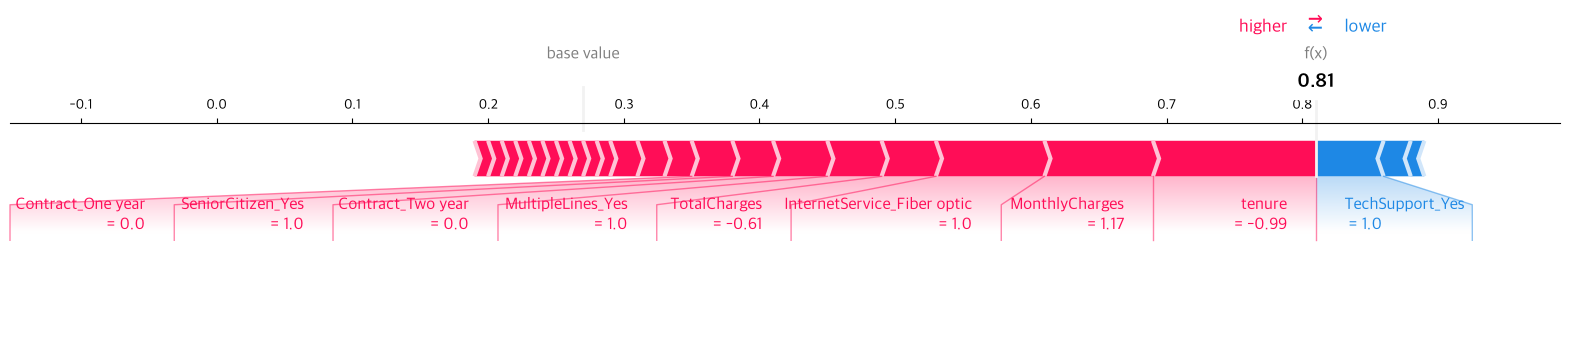

In [21]:
shap.initjs()

# 실제로 이탈(1)로 예측된 고객 중 한 명 선택
pred_best = best_model.predict(X_test_best)
churn_idx = np.where(pred_best == 1)[0]
i = churn_idx[0]  # 첫 번째 이탈 예측 고객
print(f"선택한 고객 → X_test 내 위치 {i} | 예측=이탈(1) | 실제 Churn={y_test.iloc[i]}")

# 클래스 1(이탈) 기준 base value
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)) and np.ndim(base_value) > 0:
    base_value_churn = base_value[1]
else:
    base_value_churn = base_value

# Force Plot: 어떤 변수가 이탈 예측을 밀어올렸는지(빨강)/낮췄는지(파랑) 확인
# 값은 소수점 2자리로 제한하고, 변수명 끝에 줄바꿈을 넣어
# "변수명" 은 위, "= 값" 은 아래로 표시되도록 해 가독성 향상
feat_values = X_test_best.iloc[i].round(2)
feat_values.index = [f"{name}\n" for name in feat_values.index]

shap.force_plot(
    round(float(base_value_churn), 2),
    np.round(shap_values_churn[i], 2),
    feat_values,
    matplotlib=True,
)
plt.show()

## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

In [22]:
# 이탈(1)로 예측된 고객 전체에 대해 클래스 1 SHAP 기여도를 집계
churn_mask = best_model.predict(X_test_best) == 1
shap_churn_customers = shap_values_churn[churn_mask]

# mean_shap(부호 포함): 양수일수록 이탈 예측을 '높이는' 방향으로 작용한 변수
mean_contrib = pd.DataFrame({
    "feature": list(best_features),
    "mean_shap": shap_churn_customers.mean(axis=0),
    "mean_abs_shap": np.abs(shap_churn_customers).mean(axis=0),
}).sort_values("mean_shap", ascending=False)

print(f"이탈로 예측된 고객 수: {int(churn_mask.sum())}명")
print("\n=== 이탈 예측을 높인(양의 기여) 상위 변수 ===")
display(mean_contrib.head(10).round(4))

# 상위 이탈 요인 변수 → 마케팅 액션 매핑 (원-핫 변수는 원본 변수명 기준 매핑)
suggestions = {
    "Contract": "월 단위 계약 고객에게 1~2년 약정 전환 시 요금 할인·사은품 제공",
    "tenure": "가입 초기(단기) 고객 대상 온보딩 케어 및 초기 이탈 방지 프로모션",
    "MonthlyCharges": "고요금 고객에게 요금제 최적화 상담 및 번들 할인 제안",
    "TotalCharges": "누적 요금 부담 고객에게 로열티 리워드·포인트 적립 강화",
    "InternetService": "Fiber(광랜) 품질 불만 대응 및 서비스 안정성 개선 안내",
    "PaymentMethod": "전자수표 등 이탈 위험 결제수단 고객에게 자동이체 전환 혜택 제공",
    "OnlineSecurity": "부가 보안 서비스 무료 체험 제공으로 lock-in 강화",
    "TechSupport": "기술지원 서비스 무료·할인 제공으로 만족도 개선",
    "OnlineBackup": "데이터 백업 부가서비스 프로모션으로 부가가치 제공",
    "PaperlessBilling": "청구 방식 안내 강화 및 맞춤 요금 리포트 제공",
    "DeviceProtection": "단말 보호 서비스 할인 번들로 이탈 방어",
    "StreamingTV": "OTT/스트리밍 번들 할인으로 이용 만족도 제고",
    "StreamingMovies": "OTT/스트리밍 번들 할인으로 이용 만족도 제고",
}

top_drivers = mean_contrib.head(5)["feature"].tolist()
print("\n=== 이탈 핵심 요인 기반 마케팅 제안 ===")
for feat in top_drivers:
    base = feat.split("_")[0]  # 원-핫 인코딩된 컬럼에서 원본 변수명 추출
    action = suggestions.get(base, "해당 변수 관련 맞춤 리텐션 오퍼 설계")
    print(f"- {feat}: {action}")

print(
    "\n[종합] 변수 선택(mRMR/Boruta)에서 반복적으로 살아남은 변수와 "
    "SHAP에서 이탈 기여도가 큰 변수가 겹친다면, 그 변수들이 이탈의 핵심 동인입니다. "
    "위 마케팅 제안을 우선순위로 적용해 보세요."
)

이탈로 예측된 고객 수: 293명

=== 이탈 예측을 높인(양의 기여) 상위 변수 ===


,feature,mean_shap,mean_abs_shap
0,tenure,0.1036,0.1110
2,TotalCharges,0.0561,0.0620
10,InternetService_Fiber optic,0.0508,0.0672
25,Contract_Two year,0.0297,0.0297
1,MonthlyCharges,0.0262,0.0319
28,PaymentMethod_Electronic check,0.0246,0.0419
24,Contract_One year,0.0175,0.0202
13,OnlineSecurity_Yes,0.0143,0.0229
12,OnlineSecurity_No internet service,0.0114,0.0120
18,TechSupport_No internet service,0.0100,0.0102



=== 이탈 핵심 요인 기반 마케팅 제안 ===
- tenure: 가입 초기(단기) 고객 대상 온보딩 케어 및 초기 이탈 방지 프로모션
- TotalCharges: 누적 요금 부담 고객에게 로열티 리워드·포인트 적립 강화
- InternetService_Fiber optic: Fiber(광랜) 품질 불만 대응 및 서비스 안정성 개선 안내
- Contract_Two year: 월 단위 계약 고객에게 1~2년 약정 전환 시 요금 할인·사은품 제공
- MonthlyCharges: 고요금 고객에게 요금제 최적화 상담 및 번들 할인 제안

[종합] 변수 선택(mRMR/Boruta)에서 반복적으로 살아남은 변수와 SHAP에서 이탈 기여도가 큰 변수가 겹친다면, 그 변수들이 이탈의 핵심 동인입니다. 위 마케팅 제안을 우선순위로 적용해 보세요.


## 7) 전처리 · 리샘플링 · 변수선택 병합 성능 비교

**[과제]** 써니는 Day4에서 다룬 **결측치/이상치 처리 + 리샘플링**과 Day5에서 찾은 **최적 변수 선택**을 하나로 합쳐, 처리 단계를 하나씩 추가할 때마다 성능이 얼마나 좋아지는지 순서대로 확인하고 마지막에 표로 정리해 보세요.

In [23]:
# =========================================================
# Day4(결측·이상치 처리 + 리샘플링) + Day5(변수 선택) 병합 성능 비교
#  - 결측/이상치 처리가 끝난 X_train/X_test(셀 6)를 그대로 사용
#  - 리샘플링 × 변수선택 조합별 RandomForest 성능을 평가하고
#    처리 단계를 누적하며 성능 향상 과정을 표로 정리
# =========================================================
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# 1) 후보 정의: 변수 집합 × 리샘플링 기법
feature_sets = {
    "전체 변수": list(feature_names),
    f"mRMR(k={best_k})": list(selected_mrmr),
    f"Boruta({len(selected_boruta)}개)": list(selected_boruta),
}
# 리샘플링은 학습 데이터에만 적용 (테스트는 원본 유지)
sampler_factory = {
    "리샘플링 X": None,
    "TomekLinks": lambda: TomekLinks(),
    "SMOTE": lambda: SMOTE(random_state=10),
    "SMOTE+Tomek": lambda: SMOTETomek(random_state=10),
    "ADASYN": lambda: ADASYN(random_state=10),
}

def eval_combo(cols, sampler_name):
    """선택 변수 + 리샘플링 조합으로 RF 학습 후 테스트 성능 반환"""
    X_tr, y_tr = X_train[cols], y_train
    factory = sampler_factory[sampler_name]
    if factory is not None:
        X_tr, y_tr = factory().fit_resample(X_tr, y_tr)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_test[cols])
    return get_classscore(y_test, pred)

# 2) 모든 조합 평가
rows = []
for fname, cols in feature_sets.items():
    for sname in sampler_factory:
        rows.append({"변수 집합": fname, "변수 수": len(cols), "리샘플링": sname,
                     **eval_combo(cols, sname)})
all_results = pd.DataFrame(rows)

print("=== 리샘플링 × 변수선택 전체 조합 성능 (F1 내림차순) ===")
display(all_results.sort_values("F1-score", ascending=False).round(4).reset_index(drop=True))

# 3) 처리 단계를 하나씩 누적하며 성능 향상 과정 정리
def score_of(fname, sname):
    r = all_results[(all_results["변수 집합"] == fname) & (all_results["리샘플링"] == sname)].iloc[0]
    return r[["Accuracy", "Precision", "Recall", "F1-score"]].to_dict()

base_f1 = score_of("전체 변수", "리샘플링 X")["F1-score"]

# 전체 변수 기준 최적 리샘플링 → 그 리샘플링 위에서 최적 변수 집합 선택 (누적 경로)
best_sampler = (all_results[all_results["변수 집합"] == "전체 변수"]
                .sort_values("F1-score", ascending=False).iloc[0]["리샘플링"])
best_fs_after_resample = (all_results[all_results["리샘플링"] == best_sampler]
                          .sort_values("F1-score", ascending=False).iloc[0]["변수 집합"])

steps = [
    ("① 결측·이상치 처리 (전체 변수)", "전체 변수", "리샘플링 X"),
    (f"② + 리샘플링 ({best_sampler})", "전체 변수", best_sampler),
    (f"③ + 변수 선택 ({best_fs_after_resample})", best_fs_after_resample, best_sampler),
]

prog_rows, prev_f1 = [], None
for label, fname, sname in steps:
    s = score_of(fname, sname)
    delta = "-" if prev_f1 is None else f"{s['F1-score'] - prev_f1:+.4f}"
    prog_rows.append({"처리 단계": label, **{k: round(v, 4) for k, v in s.items()},
                      "직전 단계 대비 F1": delta})
    prev_f1 = s["F1-score"]

progress = pd.DataFrame(prog_rows).set_index("처리 단계")
print("\n=== 처리 단계별 성능 향상 과정 ===")
display(progress)

# 4) 최종 최고 성능 조합
best_overall = all_results.sort_values("F1-score", ascending=False).iloc[0]
print(f"\n[최고 성능 조합] 변수집합='{best_overall['변수 집합']}' "
      f"({int(best_overall['변수 수'])}개) + 리샘플링='{best_overall['리샘플링']}'")
print(f"  F1-score = {best_overall['F1-score']:.4f} "
      f"(baseline 대비 {best_overall['F1-score'] - base_f1:+.4f})")

=== 리샘플링 × 변수선택 전체 조합 성능 (F1 내림차순) ===


,변수 집합,변수 수,리샘플링,Accuracy,Precision,Recall,F1-score
0,전체 변수,30,SMOTE+Tomek,0.7814,0.5864,0.5989,0.5926
1,전체 변수,30,TomekLinks,0.7842,0.5956,0.5829,0.5892
2,전체 변수,30,ADASYN,0.7743,0.5737,0.5829,0.5782
3,전체 변수,30,SMOTE,0.7757,0.5792,0.5668,0.5730
4,mRMR(k=10),10,SMOTE+Tomek,0.7317,0.4961,0.6738,0.5714
5,전체 변수,30,리샘플링 X,0.7963,0.6485,0.5080,0.5697
6,mRMR(k=10),10,ADASYN,0.7253,0.4872,0.6631,0.5617
7,mRMR(k=10),10,SMOTE,0.7296,0.4928,0.6364,0.5554
8,mRMR(k=10),10,TomekLinks,0.7445,0.5180,0.5374,0.5276
9,mRMR(k=10),10,리샘플링 X,0.7480,0.5255,0.5241,0.5248



=== 처리 단계별 성능 향상 과정 ===


,Accuracy,Precision,Recall,F1-score,직전 단계 대비 F1
처리 단계,,,,,
① 결측·이상치 처리 (전체 변수),0.7963,0.6485,0.5080,0.5697,-
② + 리샘플링 (SMOTE+Tomek),0.7814,0.5864,0.5989,0.5926,+0.0229
③ + 변수 선택 (전체 변수),0.7814,0.5864,0.5989,0.5926,+0.0000



[최고 성능 조합] 변수집합='전체 변수' (30개) + 리샘플링='SMOTE+Tomek'
  F1-score = 0.5926 (baseline 대비 +0.0229)


## 8) [검증 1] 변수 선택은 선형모델에 더 도움이 된다

RandomForest는 다중공선성에 둔감해 변수를 줄이면 정보 손실로 F1이 하락하는 경향이 있습니다.
반대로 **로지스틱 회귀(선형모델)** 는 다중공선성에 민감하므로, mRMR/Boruta로 변수를 정리하면 전체 변수 대비 F1이 유지되거나 개선되는지 비교해 봅니다.

=== 변수 선택 × 모델별 F1 비교 ===


,변수 수,RandomForest F1,LogisticRegression F1,RF Δ(vs 전체),LR Δ(vs 전체)
변수 집합,,,,,
전체 변수,30,0.5697,0.5945,0.0000,0.0000
mRMR(k=10),10,0.5248,0.5685,-0.0449,-0.0260
Boruta(3개),3,0.4715,0.4913,-0.0982,-0.1032


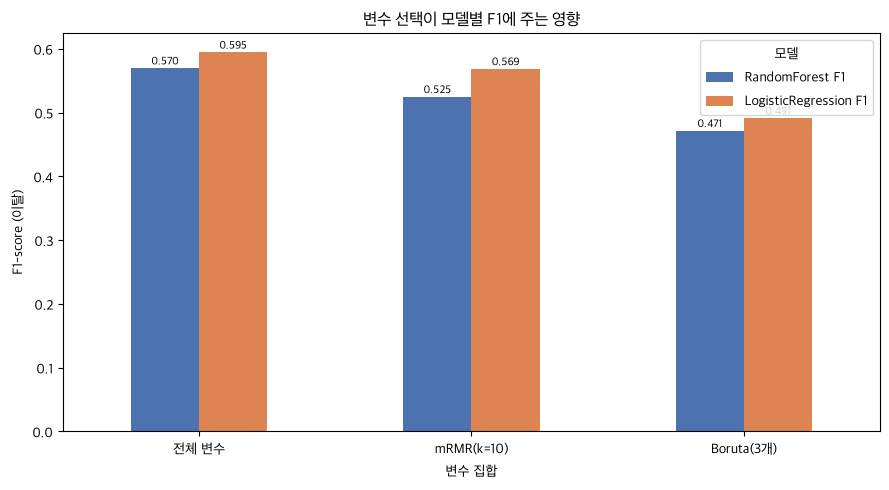

[해석] RF는 다중공선성에 둔감 → 변수를 줄이면 정보 손실로 F1이 하락하는 경향.
       로지스틱 회귀는 변수 정리 시 전체 변수 대비 F1이 유지/개선되면 '변수 선택은 선형모델에 더 유용'하다는 주장과 일치.


In [24]:
from sklearn.linear_model import LogisticRegression

# 같은 변수 집합을 RF와 로지스틱 회귀에 각각 학습시켜 F1 비교
feature_sets_demo = {
    "전체 변수": list(feature_names),
    f"mRMR(k={best_k})": list(selected_mrmr),
    f"Boruta({len(selected_boruta)}개)": list(selected_boruta),
}

def f1_of(model_ctor, cols):
    m = model_ctor()
    m.fit(X_train[cols], y_train)
    return f1_score(y_test, m.predict(X_test[cols]), zero_division=0)

rows = []
for name, cols in feature_sets_demo.items():
    rows.append({
        "변수 집합": name,
        "변수 수": len(cols),
        "RandomForest F1": round(f1_of(lambda: RandomForestClassifier(n_estimators=100, random_state=42), cols), 4),
        "LogisticRegression F1": round(f1_of(lambda: LogisticRegression(max_iter=1000, random_state=42), cols), 4),
    })
compare_models = pd.DataFrame(rows).set_index("변수 집합")

# 전체 변수 대비 변화량(Δ)
base_rf = compare_models.loc["전체 변수", "RandomForest F1"]
base_lr = compare_models.loc["전체 변수", "LogisticRegression F1"]
compare_models["RF Δ(vs 전체)"] = (compare_models["RandomForest F1"] - base_rf).round(4)
compare_models["LR Δ(vs 전체)"] = (compare_models["LogisticRegression F1"] - base_lr).round(4)

print("=== 변수 선택 × 모델별 F1 비교 ===")
display(compare_models)

# 시각화
ax = compare_models[["RandomForest F1", "LogisticRegression F1"]].plot(
    kind="bar", figsize=(9, 5), rot=0, color=["#4C72B0", "#DD8452"]
)
ax.set_title("변수 선택이 모델별 F1에 주는 영향")
ax.set_ylabel("F1-score (이탈)")
ax.legend(title="모델")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()

print("[해석] RF는 다중공선성에 둔감 → 변수를 줄이면 정보 손실로 F1이 하락하는 경향.")
print("       로지스틱 회귀는 변수 정리 시 전체 변수 대비 F1이 유지/개선되면 '변수 선택은 선형모델에 더 유용'하다는 주장과 일치.")

## 9) [검증 2] mRMR 변수 개수(k)에 따른 F1 곡선

mRMR로 선택하는 변수 수 k를 늘려가며 RF의 F1을 측정합니다.
**적은 변수만으로도 전체 변수 성능에 얼마나 근접하는지**(= 소수 변수로 충분한지)를 곡선으로 확인합니다.

100%|██████████| 30/30 [00:04<00:00,  6.18it/s]


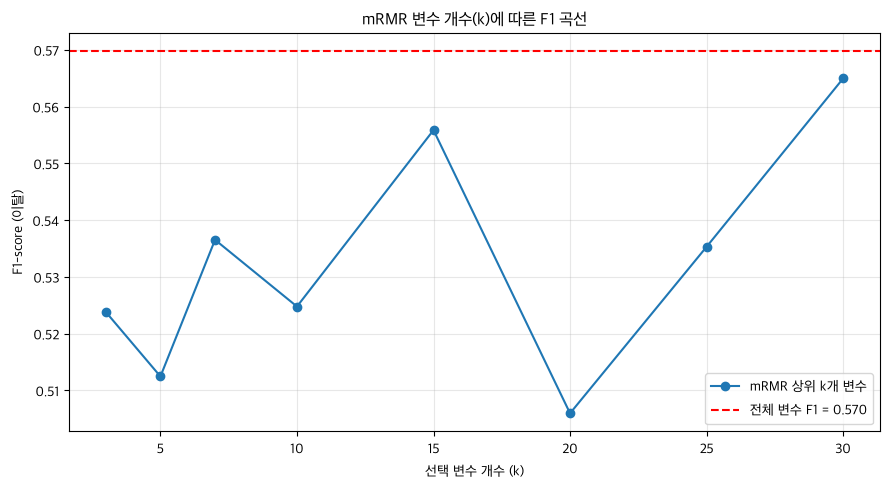

,k,F1-score,전체 대비 Δ
0,3,0.5238,-0.0459
1,5,0.5124,-0.0573
2,7,0.5365,-0.0332
3,10,0.5248,-0.0449
4,15,0.5559,-0.0139
5,20,0.5060,-0.0638
6,25,0.5353,-0.0344
7,30,0.5650,-0.0048


[해석] 전체 변수(30개) F1=0.5697 대비, 적은 k에서 이미 성능이 거의 근접한다면 '소수 변수로 충분(해석·경량화 이점)'하다는 근거가 됩니다.


In [25]:
# mRMR 상위 k개 변수로 RF를 학습하며 k에 따른 F1 변화 측정
k_grid = sorted(set(k for k in [3, 5, 7, 10, 15, 20, 25, X_train.shape[1]] if k <= X_train.shape[1]))

f1_curve = []
for k in k_grid:
    cols = mrmr_classif(X=X_train, y=y_train, K=k)
    m = RandomForestClassifier(n_estimators=100, random_state=42)
    m.fit(X_train[cols], y_train)
    f1_curve.append(f1_score(y_test, m.predict(X_test[cols]), zero_division=0))

# 전체 변수 기준 F1 (셀 11의 rf_all 재사용)
full_f1 = f1_score(y_test, rf_all.predict(X_test), zero_division=0)

plt.figure(figsize=(9, 5))
plt.plot(k_grid, f1_curve, marker="o", label="mRMR 상위 k개 변수")
plt.axhline(full_f1, color="red", ls="--", label=f"전체 변수 F1 = {full_f1:.3f}")
plt.xlabel("선택 변수 개수 (k)")
plt.ylabel("F1-score (이탈)")
plt.title("mRMR 변수 개수(k)에 따른 F1 곡선")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

curve_df = pd.DataFrame({
    "k": k_grid,
    "F1-score": np.round(f1_curve, 4),
    "전체 대비 Δ": np.round(np.array(f1_curve) - full_f1, 4),
})
display(curve_df)
print(f"[해석] 전체 변수({X_train.shape[1]}개) F1={full_f1:.4f} 대비, "
      "적은 k에서 이미 성능이 거의 근접한다면 '소수 변수로 충분(해석·경량화 이점)'하다는 근거가 됩니다.")

## 10) [검증 3] 회귀 데이터셋에서 변수 선택 효과 확인

앞선 분류(Churn) 데이터에서는 변수 선택이 RF 성능을 오히려 떨어뜨렸습니다.
이번엔 `Day5-2 SHAP` 노트북에서 쓴 **회귀 데이터셋(`day5-2_reg_data.csv`, 58개 변수)** 으로 바꿔서,
mRMR / SHAP 기반 변수 선택이 성능 지표(R², MAE)를 **개선하는지** 확인합니다.
특히 다중공선성에 민감한 **LinearRegression** 과 둔감한 **RandomForest** 를 함께 비교합니다.

In [27]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from mrmr import mrmr_regression

# 회귀 데이터셋 로드 (Day5-2 SHAP 노트북과 동일 데이터)
reg = pd.read_csv("dataset/day5-2_reg_data.csv")
Xr = reg.drop(columns=["y"])
yr = reg["y"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)
print("회귀 데이터:", Xr.shape, "| 변수 수:", Xr.shape[1])

def reg_scores(true, pred):
    return {
        "MAE": mean_absolute_error(true, pred),
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "R2": r2_score(true, pred),
    }

def fit_eval_reg(model_ctor, cols):
    m = model_ctor()
    m.fit(Xr_train[cols], yr_train)
    return reg_scores(yr_test, m.predict(Xr_test[cols]))

lin_ctor = lambda: LinearRegression()
rf_ctor = lambda: RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0)

all_cols = list(Xr.columns)
print("\n[전체 변수] LinearRegression:", {k: round(v, 3) for k, v in fit_eval_reg(lin_ctor, all_cols).items()})
print("[전체 변수] RandomForest   :", {k: round(v, 3) for k, v in fit_eval_reg(rf_ctor, all_cols).items()})

회귀 데이터: (241, 58) | 변수 수: 58

[전체 변수] LinearRegression: {'MAE': 2.255, 'RMSE': np.float64(2.996), 'R2': 0.398}
[전체 변수] RandomForest   : {'MAE': 1.991, 'RMSE': np.float64(2.569), 'R2': 0.558}


In [30]:
import shap

k_candidates = [5, 10, 15, 20, 30, 40]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- mRMR: LinearRegression 기준 CV R^2이 가장 높은 k 선택 ---
mrmr_cv = {}
for k in k_candidates:
    cols = mrmr_regression(X=Xr_train, y=yr_train, K=k)
    mrmr_cv[k] = cross_val_score(LinearRegression(), Xr_train[cols], yr_train, cv=kf, scoring="r2").mean()
    print(f"[mRMR] k={k:>2}, CV R2={mrmr_cv[k]:.4f}")
best_k_reg = max(mrmr_cv, key=mrmr_cv.get)
mrmr_cols = mrmr_regression(X=Xr_train, y=yr_train, K=best_k_reg)
print(f">>> mRMR 최적 k = {best_k_reg} (CV R2={mrmr_cv[best_k_reg]:.4f})\n")

# --- SHAP: RandomForest 학습 후 mean|SHAP| 기반 변수 선택 ---
# k를 억지로 맞추지 않고, 누적 SHAP 기여도가 전체의 95%에 도달하는 최소 변수 집합을 선택
rf_full = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0)
rf_full.fit(Xr_train, yr_train)
explainer_r = shap.TreeExplainer(rf_full)
sv = explainer_r.shap_values(Xr_train)
shap_rank = pd.Series(np.abs(sv).mean(axis=0), index=Xr.columns).sort_values(ascending=False)

cum_ratio = shap_rank.cumsum() / shap_rank.sum()
n_shap = int((cum_ratio < 0.95).sum() + 1)   # 누적 기여도가 95%에 도달하는 데 필요한 변수 수
shap_cols = shap_rank.head(n_shap).index.tolist()
print(f"SHAP 누적 기여도 95% 도달에 필요한 변수 수: {n_shap}개")
print(f"SHAP 선택 변수: {shap_cols}")

100%|██████████| 5/5 [00:00<00:00,  5.14it/s]


[mRMR] k= 5, CV R2=0.5276


100%|██████████| 10/10 [00:00<00:00, 21.59it/s]


[mRMR] k=10, CV R2=0.5491


100%|██████████| 15/15 [00:00<00:00, 29.73it/s]


[mRMR] k=15, CV R2=0.5319


100%|██████████| 20/20 [00:00<00:00, 29.21it/s]


[mRMR] k=20, CV R2=0.5081


100%|██████████| 30/30 [00:01<00:00, 26.57it/s]


[mRMR] k=30, CV R2=0.4503


100%|██████████| 40/40 [00:01<00:00, 38.31it/s]


[mRMR] k=40, CV R2=0.3919


100%|██████████| 10/10 [00:00<00:00, 49.78it/s]


>>> mRMR 최적 k = 10 (CV R2=0.5491)

SHAP 누적 기여도 95% 도달에 필요한 변수 수: 43개
SHAP 선택 변수: ['X10', 'X3', 'X46', 'X26', 'X33', 'X2', 'X25', 'X37', 'X15', 'X16', 'X34', 'X51', 'X58', 'X24', 'X44', 'X4', 'X18', 'X27', 'X8', 'X45', 'X7', 'X11', 'X1', 'X20', 'X52', 'X5', 'X30', 'X57', 'X14', 'X6', 'X55', 'X17', 'X19', 'X9', 'X48', 'X31', 'X53', 'X50', 'X23', 'X13', 'X36', 'X56', 'X35']


=== 회귀 데이터: 변수 선택 × 모델별 성능 비교 ===


,변수 수,Lin R2,Lin MAE,RF R2,RF MAE,Lin R2 Δ,RF R2 Δ
변수 집합,,,,,,,
전체 변수(58개),58,0.3984,2.255,0.5577,1.991,0.0000,0.0000
mRMR(k=10),10,0.6007,1.823,0.5268,2.125,0.2023,-0.0309
"SHAP(95%, 43개)",43,0.4807,2.134,0.5535,2.009,0.0823,-0.0042


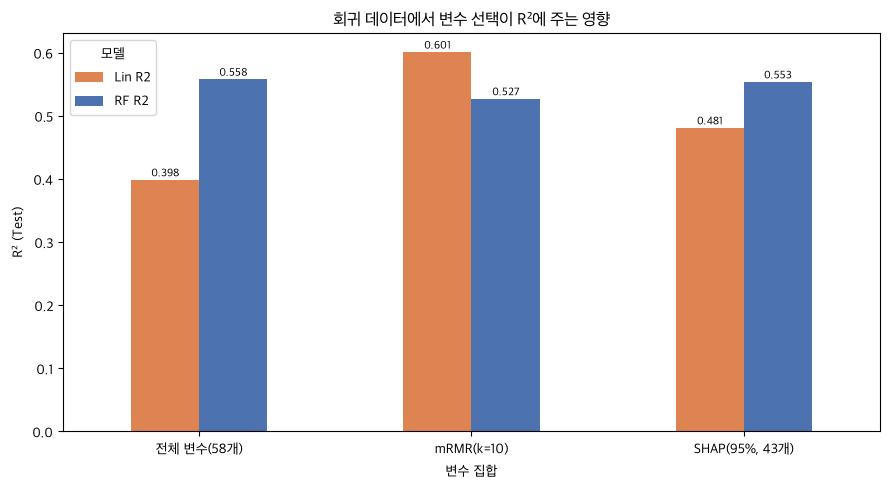

[해석] 전체 변수 대비 mRMR/SHAP 선택 시 R2 Δ가 양수(+)면 변수 선택이 성능을 '개선'한 것.
       특히 LinearRegression에서 개선폭이 크면, 다중공선성에 민감한 선형/회귀 문제에서
       변수 선택이 더 효과적이라는 앞선 주장과 일치합니다.


In [31]:
# 전체 변수 vs mRMR vs SHAP 선택 변수 → Linear/RF 성능 비교
feature_sets_reg = {
    f"전체 변수({len(all_cols)}개)": all_cols,
    f"mRMR(k={best_k_reg})": mrmr_cols,
    f"SHAP(95%, {len(shap_cols)}개)": shap_cols,
}

rows = []
for name, cols in feature_sets_reg.items():
    lin_s = fit_eval_reg(lin_ctor, cols)
    rf_s = fit_eval_reg(rf_ctor, cols)
    rows.append({
        "변수 집합": name, "변수 수": len(cols),
        "Lin R2": round(lin_s["R2"], 4), "Lin MAE": round(lin_s["MAE"], 3),
        "RF R2": round(rf_s["R2"], 4), "RF MAE": round(rf_s["MAE"], 3),
    })
reg_compare = pd.DataFrame(rows).set_index("변수 집합")

# 전체 변수 대비 R² 개선폭(Δ)
base_lin_r2 = reg_compare.iloc[0]["Lin R2"]
base_rf_r2 = reg_compare.iloc[0]["RF R2"]
reg_compare["Lin R2 Δ"] = (reg_compare["Lin R2"] - base_lin_r2).round(4)
reg_compare["RF R2 Δ"] = (reg_compare["RF R2"] - base_rf_r2).round(4)

print("=== 회귀 데이터: 변수 선택 × 모델별 성능 비교 ===")
display(reg_compare)

ax = reg_compare[["Lin R2", "RF R2"]].plot(
    kind="bar", figsize=(9, 5), rot=0, color=["#DD8452", "#4C72B0"]
)
ax.set_title("회귀 데이터에서 변수 선택이 R²에 주는 영향")
ax.set_ylabel("R² (Test)")
ax.legend(title="모델")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()

print("[해석] 전체 변수 대비 mRMR/SHAP 선택 시 R2 Δ가 양수(+)면 변수 선택이 성능을 '개선'한 것.")
print("       특히 LinearRegression에서 개선폭이 크면, 다중공선성에 민감한 선형/회귀 문제에서")
print("       변수 선택이 더 효과적이라는 앞선 주장과 일치합니다.")